In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import new_utils
import prep_utils
import plot_funcs
import helper_utils

In [2]:
def load_data(file_path):
    """Automatically loads CSV or Excel files into a pandas DataFrame."""
    # Extract the file extension in lowercase
    ext = os.path.splitext(file_path)[1].lower()
    
    if ext == '.csv':
        return pd.read_csv(file_path)
    elif ext in ['.xlsx', '.xls']:
        return pd.read_excel(file_path)
    else:
        raise ValueError(f"Unsupported file format: {ext}")



def trad_spec(data_df, detect_columns, fig_size=helper_utils.FIG_SIZE, dpi=helper_utils.DPI, ):
    df_plot_data, should_exit_early, has_any_nist = prep_utils.prep_with_nist(data_df = data_df, detect_columns=detect_columns,)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig
    fig, ax = plot_funcs.plot(df_plot_data = df_plot_data, nm_col = helper_utils.wl_col, has_any_nist=has_any_nist)
    return fig



def plot_other_spec(data_df, graph_type,detect_columns, save_path=None):
    helper_utils.get_graph_type()       # needs to be able to use graph_type from webapp3.py / index.html
    if graph_type == 'traditional':
        trad_spec(data_df=data_df)
    else:
        data_df, should_exit_early = prep_utils.prep_other(data_df = data_df, detect_columns=detect_columns,)
        if should_exit_early:
            fig, ax = plt.subplots(figsize=new_utils.fig_size, dpi=helper_utils.DPI)
            ax.set_axis_off()
            print("Ending Rendering Early.")
            return fig
        new_utils.show_peak_labels()
        new_utils.axis_labels()

        if helper_utils.rgb_type == 'yes':
            new_utils.scale_by_int()

        if helper_utils.graph_type == 'bar':
            plot_funcs.bar_iteration(data_df = data_df)
        elif helper_utils.graph_type == 'scatter':
            plot_funcs.scatter_iteration(data_df = data_df)
        elif helper_utils.graph_type == 'gaussian':
            plot_funcs.gaussian_iteration(df_plot_data= data_df)
        elif helper_utils.graph_type == 'line':
            plot_funcs.line_plot_iteration(data_df=data_df)
        elif helper_utils.graph_type == 'filled line':
            plot_funcs.filled_plot(data_df = data_df)
        elif helper_utils.graph_type == 'non rgb line':
            plot_funcs.non_rgb_iteration(data_df=data_df)

        if save_path:
            try:
                fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=helper_utils.dpi)
            except Exception:
                plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=helper_utils.dpi)



def detect_prep(
    data_df, 
    force_nist = None, 
    graph_type=None,
    title=None,
    random_title=None,
    mode = 'dark',
    show_peak_labels=True,
    scale_mode = 'auto',
):
    df_data, has_any_nist = prep_utils.run_nist_check(data_df=data_df, force_nist=force_nist)
    if has_any_nist is True:
        prep_type = 'nist'
        nist_plot_type = input("NIST Descriptors Detected. Choose NIST Graph Type: Gaussian or Traditional").lower()
        if nist_plot_type == 'gaussian' or nist_plot_type == 'g':
            helper_utils.graph_type = 'gaussian'
            new_utils.axis_labels()
            plot_funcs.gaussian_iteration(df_plot_data = df_data)
        if nist_plot_type == 'traditional' or nist_plot_type == 'trad' or nist_plot_type == 't':
            scale_mode = 'raw'
            helper_utils.graph_type = 'traditional'
            trad_spec(data_df = df_data)
    else:
        prep_type = 'generic'
        plot_other_spec(data_df=df_data)
    return prep_type, helper_utils.graph_type, scale_mode


In [3]:
def axis_labels(
    mode,
    fig_size = helper_utils.fig_size,
    reverse_x = helper_utils.reverse_x,
    x_min = helper_utils.X_MIN,
    x_max = helper_utils.X_MAX,
    x_title = helper_utils.X_TITLE,
    y_title = helper_utils.Y_TITLE,
    text = None,
    y_min = 0,
    y_max = 0,
):
    
    plt.figure(figsize=fig_size)
    ax = plt.gca()
    new_utils.text_colour(mode=mode)
    show = input("Show Grid? Yes or No").lower()

    if mode == 'dark':
        fig_bg = new_utils.bg
        text = new_utils.colour
        plt.gcf().set_facecolor(fig_bg)
        for spine in ax.spines.values():        # new block. may have to take out or decrease linewidth. 
            spine.set_linewidth(0.3)
            spine.set_color('darkgrey')
        if show == 'yes' or show == 'y':
            plt.grid(True, color='darkgrey', linewidth=0.25)   # took out 'linestyle = ':' '    may have to add back in. 
        elif show == 'no' or show == 'n':
            plt.grid(False)
    else:
        fig_bg = new_utils.bg
        text = new_utils.colour
        for spine in ax.spines.values():       # new block
            spine.set_linewidth(0.5)
        if show == 'yes' or show == 'y':
            plt.grid(True)
        elif show == 'no' or show == 'n':
            plt.grid(False)

    reverse_x = (input("Reverse x-axis? Yes or No")).lower()
    if reverse_x == 'yes' or reverse_x == 'y':
        reverse_x is True
        plt.xlim(x_max, x_min)
    else:
        reverse_x is False
        plt.xlim(x_min, x_max)

    y_max = new_utils.set_y_lim()

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)
    ax.yaxis.set_major_locator(helper_utils.major_locator)
    plt.title(f'{helper_utils.graph_type.title()} Plot', color = new_utils.colour)        # set_title()
    plt.ylim(y_min, y_max)


'''
# need to make this so that it works with web code

def set_title():
    t = input("Choose: Custom or Random Title?").lower()
    if t == 'c':
        title = input("Enter Custom Title")
        plt.title(str(title).strip(), color=new_utils.colour, y=1.0, pad=10)
    if t == 'r':
        plt.title(new_utils.generate_random_title(), color=new_utils.colour, y=1.0, pad=10)
'''

'\n# need to make this so that it works with web code\n\ndef set_title():\n    t = input("Choose: Custom or Random Title?").lower()\n    if t == \'c\':\n        title = input("Enter Custom Title")\n        plt.title(str(title).strip(), color=new_utils.colour, y=1.0, pad=10)\n    if t == \'r\':\n        plt.title(new_utils.generate_random_title(), color=new_utils.colour, y=1.0, pad=10)\n'

In [4]:
def get_rgb_type(graph_type):
    global rgb_type
    if graph_type != 'non rgb line':
        rgb_type = 'yes'

In [5]:
def plot(
    data_df,
    detect_columns,
    force_nist = None,
    graph_type = None,
    mode = 'dark',
    scale_mode = 'auto',
    title = None,
    random_title = None,
    show_peak_labels = None,
    show_grid = True,
    show_label_colour = None,
    scale_by_int = None,
    save_path=None,
):
    df_data, has_any_nist, _cols = prep_utils.run_nist_check(data_df=data_df, detect_columns=detect_columns, force_nist=force_nist)
    if has_any_nist is True:
        prep_type = 'nist'
        nist_plot_type = 'g' or 'gaussian' or 't' or 'traditional'
        if nist_plot_type == 'g' or nist_plot_type == 'gaussian':
            graph_type = 'gaussian'
            axis_labels(mode=mode)
            plot_funcs.gaussian_iteration(df_plot_data=df_data, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode, detect_columns=detect_columns,)
        if nist_plot_type =='t' or nist_plot_type == 'traditional':
            scale_mode = 'raw'
            graph_type = 'traditional'
            trad_spec(data_df=data_df, mode=mode, scale_mode=scale_mode, show_peak_labels=show_peak_labels, title=title, random_title=random_title)

    else:
        prep_type = 'generic'
        if graph_type == 'traditional':
            trad_spec(data_df=data_df, mode=mode, scale_mode=scale_mode, show_peak_labels=show_peak_labels, title=title, random_title=random_title)
        else:
            data_df, should_exit_early = prep_utils.prep_other(data_df = data_df, detect_columns=detect_columns,)
            if should_exit_early:
                fig, ax = plt.subplots(figsize=new_utils.fig_size, dpi=helper_utils.DPI)
                ax.set_axis_off()
                print("Ending Rendering Early.")
                return fig

        axis_labels(mode=mode)
        if rgb_type == 'yes':
            scale_by_int=scale_by_int


        if graph_type == 'bar':
            plot_funcs.bar_iteration(data_df = data_df, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode, scale_by_int=scale_by_int)
        elif graph_type == 'scatter':
            plot_funcs.scatter_iteration(data_df = data_df, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode, scale_by_int=scale_by_int)
        elif graph_type == 'gaussian':
            plot_funcs.gaussian_iteration(df_plot_data=data_df, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode, scale_by_int=False)
        elif graph_type == 'line':
            plot_funcs.line_plot_iteration(data_df = data_df, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode, scale_by_int=scale_by_int)
        elif graph_type == 'filled line':
            plot_funcs.filled_plot(data_df = data_df, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode, scale_by_int=scale_by_int)
        elif graph_type == 'non rgb line':
            plot_funcs.non_rgb_iteration(data_df = data_df, show_peak_labels=show_peak_labels, show_label_colour=show_label_colour, mode=mode)


    if save_path:
            try:
                fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=helper_utils.dpi)
            except Exception:
                plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=helper_utils.dpi)

In [6]:
H_SHEET = "h test.xlsx"
HE_SHEET = "he test.xlsx"
NIST_SHEET = "oxygen nist 2.xlsx"

H_CSV_SHEET = "h test.csv"

H_DF = load_data(H_SHEET)
HE_DF = load_data(HE_SHEET)
NIST_DF = load_data(NIST_SHEET)

H_CSV_DF = load_data(H_CSV_SHEET)

global df  
df = NIST_DF

print(H_DF.head())

   Unnamed: 0  Unnamed: 1  Unnamed: 2
0         NaN       8.367   774.51129
1         NaN       9.796   773.38503
2         NaN       9.329   772.25877
3         NaN       9.808   771.13251
4         NaN       9.646   770.00625


TypeError: set_y_lim() missing 2 required positional arguments: 'graph_type' and 'show_peak_labels'

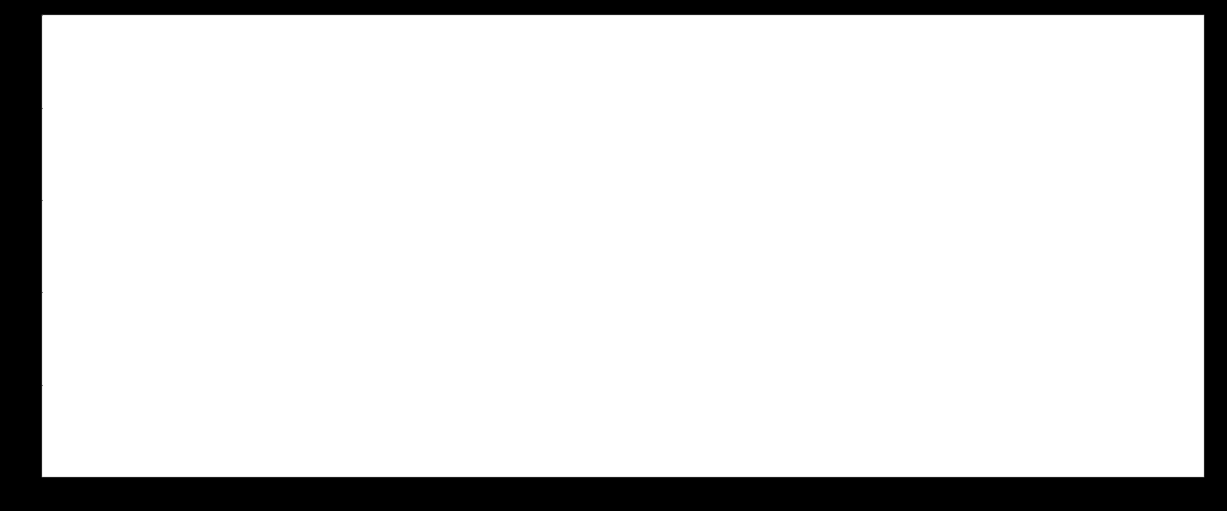

In [9]:
plot(H_DF, True)